In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded")

Libraries loaded


# Customer Churn Prediction — Exploratory Data Analysis

## Objective
Understand the structure, quality, and patterns in the 
Telco Customer Churn dataset before building an ML model.

---

## 1. Dataset Overview
Loading the raw dataset and examining its basic structure 
— shape, column names, and sample records.

In [4]:
# ── Cell 2 — Load & Basic Info ──────────────────────────────────────────

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Shape
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Rows    : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")

# Column names grouped nicely
print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col}")

# Data types
print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes.to_string())

# First 5 rows
print("\n" + "=" * 50)
print("SAMPLE DATA (first 5 rows)")
print("=" * 50)
df.head()

DATASET OVERVIEW
Total Rows    : 7,043
Total Columns : 21

COLUMN NAMES
  01. customerID
  02. gender
  03. SeniorCitizen
  04. Partner
  05. Dependents
  06. tenure
  07. PhoneService
  08. MultipleLines
  09. InternetService
  10. OnlineSecurity
  11. OnlineBackup
  12. DeviceProtection
  13. TechSupport
  14. StreamingTV
  15. StreamingMovies
  16. Contract
  17. PaperlessBilling
  18. PaymentMethod
  19. MonthlyCharges
  20. TotalCharges
  21. Churn

DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float6

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Observations
- Dataset contains **7,043 customer records** with **21 features**
- Mix of demographic, service, and billing information
- Target variable is `Churn` — whether customer left or not

## 2. Data Quality Check
Examining missing values, data types, and basic statistics
to identify any data quality issues before analysis.

In [10]:
# ── Cell 3 — Data Quality Check ─────────────────────────────────────────

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])
print("\nNo missing values found" if missing.sum() == 0 else "")

print("\n" + "=" * 50)
print("DATA TYPES SUMMARY")
print("=" * 50)
print(f"Numerical columns : {df.select_dtypes(include='number').columns.tolist()}")
print(f"Categorical columns: {df.select_dtypes(include='object').columns.tolist()}")

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe().round(2)

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

No missing values found

DATA TYPES SUMMARY
Numerical columns : ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

BASIC STATISTICS


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


### Observations
- **No missing values** found across all 21 columns
- Dataset is clean and ready for analysis
- **3 numerical columns** — `SeniorCitizen`, `tenure`, `MonthlyCharges`
- **18 categorical columns** — most service-related features
- `TotalCharges` is showing as **object (text)** instead of number
  - Reason: some rows contain a space `" "` instead of a numeric value
  - Fix: convert to numeric using `pd.to_numeric(errors='coerce')`
- Average customer tenure is **32 months** (~2.7 years)
- Monthly charges range from **$18 to $118** with mean of **$64**
- Only **16% are senior citizens** — mostly younger customers

## 3.Data Cleaning

In [13]:
# ── Cell 4 — Fix TotalCharges ────────────────────────────────────────────

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("=" * 50)
print("DATA CLEANING")
print("=" * 50)
print(f"TotalCharges dtype before : object")
print(f"TotalCharges dtype after  : {df['TotalCharges'].dtype}")
print(f"Missing values after fix  : {df['TotalCharges'].isnull().sum()}")
print("\nData cleaning complete")

DATA CLEANING
TotalCharges dtype before : object
TotalCharges dtype after  : float64
Missing values after fix  : 0

Data cleaning complete


## 4. Target Variable Analysis
Understanding the distribution of our target variable `Churn`
— how many customers left vs stayed.

CHURN DISTRIBUTION
  No    → 5,174 customers (73.5%)
  Yes   → 1,869 customers (26.5%)


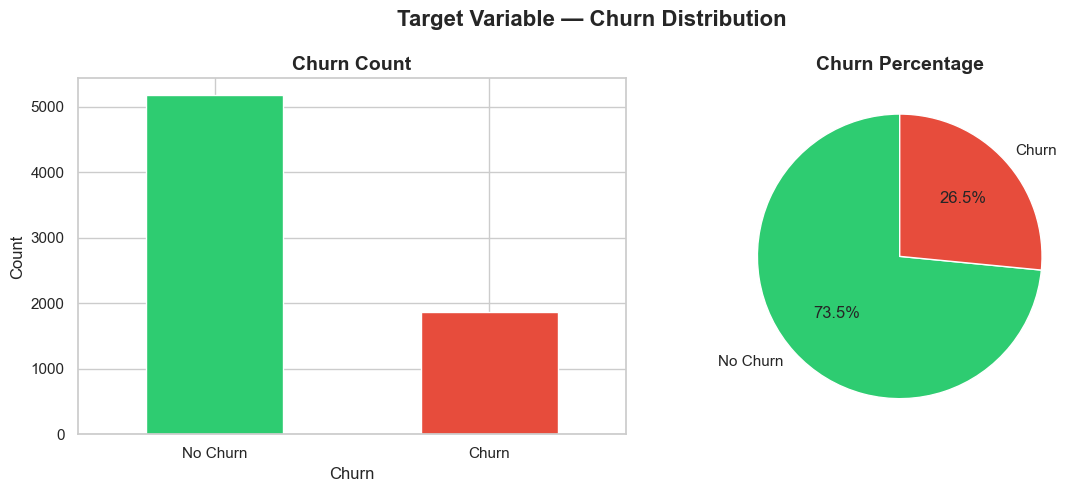

In [21]:
# ── Cell 5 — Churn Distribution ──────────────────────────────────────────

print("=" * 50)
print("CHURN DISTRIBUTION")
print("=" * 50)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

for label, count, pct in zip(churn_counts.index, churn_counts.values, churn_pct.values):
    print(f"  {label:5s} → {count:,} customers ({pct:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
churn_counts.plot(kind='bar', ax=axes[0],
                  color=['#2ecc71', '#e74c3c'],
                  edgecolor='white', width=0.5)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['No Churn', 'Churn'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable — Churn Distribution',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Univariate Analysis
Examining the distribution of key numerical features
to understand customer behaviour patterns.

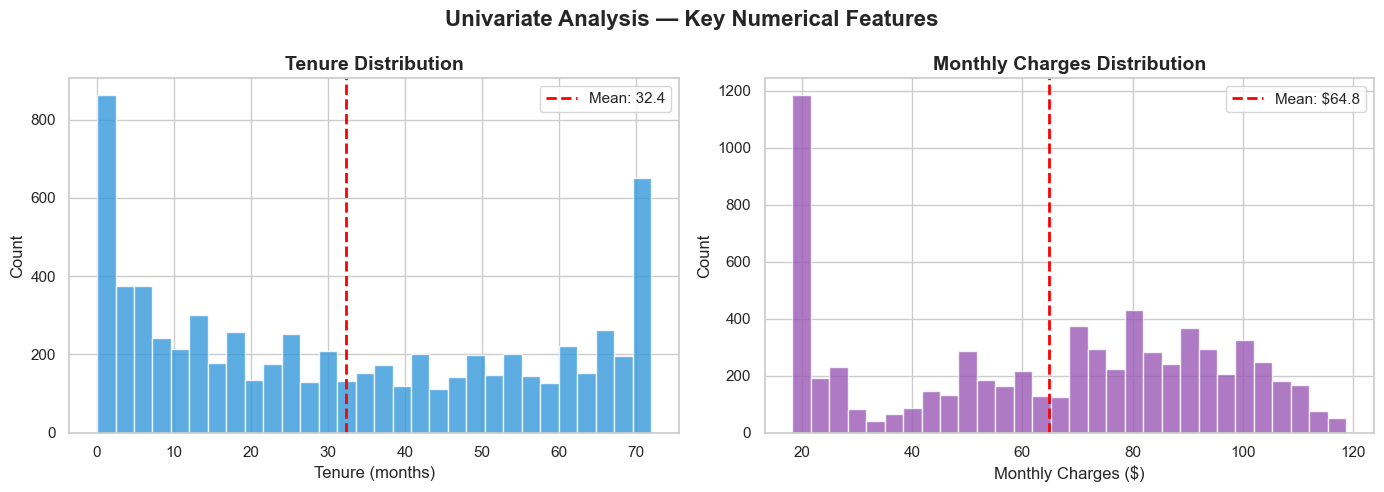

In [20]:
# ── Cell 6 — Univariate Analysis ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution
axes[0].hist(df['tenure'], bins=30, color='#3498db', 
             edgecolor='white', alpha=0.8)
axes[0].set_title('Tenure Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['tenure'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f"Mean: {df['tenure'].mean():.1f}")
axes[0].legend()

# Monthly Charges distribution
axes[1].hist(df['MonthlyCharges'], bins=30, color='#9b59b6',
             edgecolor='white', alpha=0.8)
axes[1].set_title('Monthly Charges Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].axvline(df['MonthlyCharges'].mean(), color='red',
                linestyle='--', linewidth=2, label=f"Mean: ${df['MonthlyCharges'].mean():.1f}")
axes[1].legend()

plt.suptitle('Univariate Analysis — Key Numerical Features',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### Observations
- **Tenure** is bimodal — large spike at 0-5 months (new customers)
  and another at 60-72 months (loyal long-term customers)
- Very few customers in the **middle tenure range**
- **Monthly Charges** shows two groups:
  - Budget customers around **$20** (basic plans)
  - Premium customers concentrated around **$70-80**
- Mean monthly charge is **$64.76**

## 6. Bivariate Analysis
Examining how key features relate to churn behaviour
— understanding what drives customers to leave.

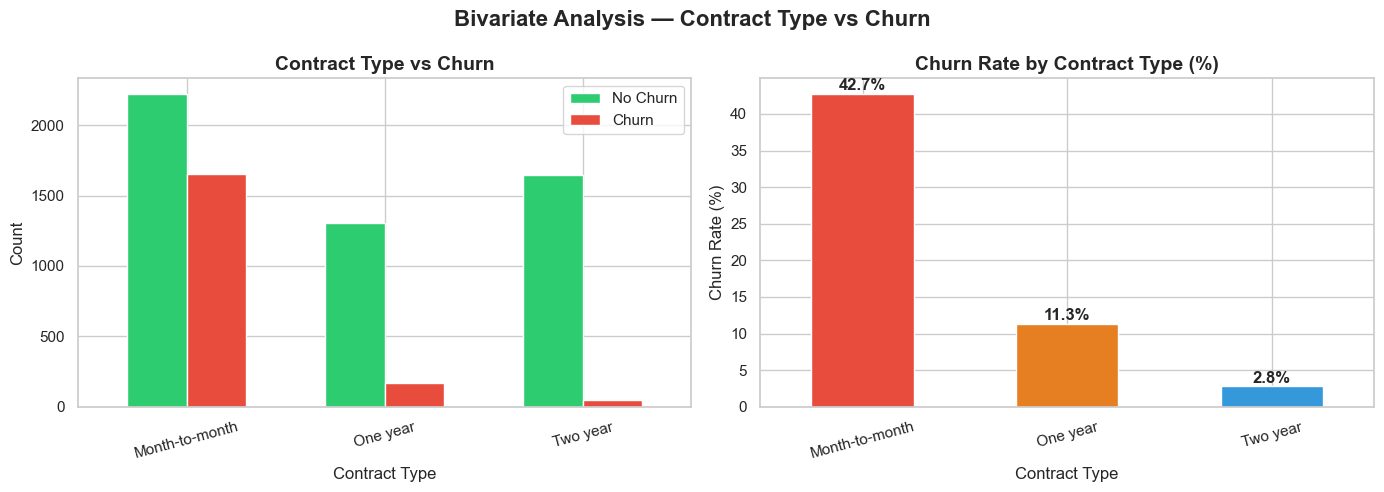

In [24]:
# ── Cell 7 — Churn vs Contract Type ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0],
                    color=['#2ecc71', '#e74c3c'],
                    edgecolor='white', width=0.6)
axes[0].set_title('Contract Type vs Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(['No Churn', 'Churn'])

# Churn rate by contract
churn_rate = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

churn_rate.plot(kind='bar', ax=axes[1],
                color=['#e74c3c', '#e67e22', '#3498db'],
                edgecolor='white', width=0.5)
axes[1].set_title('Churn Rate by Contract Type (%)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

# Add value labels on bars
for i, v in enumerate(churn_rate.values):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.suptitle('Bivariate Analysis — Contract Type vs Churn',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- **Month-to-month** contracts have the highest churn rate (~42%)
- **One year** contracts churn at ~11%
- **Two year** contracts churn at only ~3%
- Key insight: customers without long-term commitment leave easily
- **Business recommendation:** Encourage customers to switch to
  longer contracts through discounts or loyalty rewards

## 6.1. Churn vs Monthly Charges & Tenure
Examining how billing amount and customer loyalty 
relate to churn behaviour.

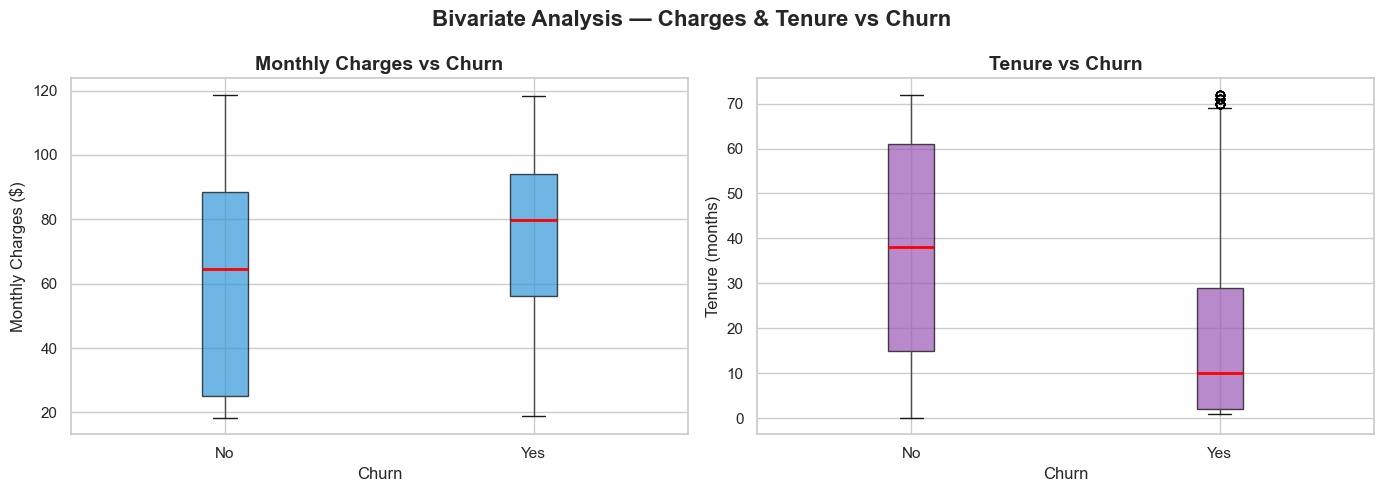

In [28]:
# ── Cell 8 — Churn vs Monthly Charges & Tenure ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')
plt.sca(axes[0])
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')

# Box plot — Tenure vs Churn
df.boxplot(column='tenure', by='Churn', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#9b59b6', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Tenure vs Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')
plt.sca(axes[1])
plt.title('Tenure vs Churn', fontsize=14, fontweight='bold')

plt.suptitle('Bivariate Analysis — Charges & Tenure vs Churn',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/charges_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- Customers who **churned** have significantly **higher monthly charges**
  - Churned median: ~$79 vs Stayed median: ~$61
- Customers who **churned** have much **lower tenure**
  - Churned median: ~10 months vs Stayed median: ~38 months
- Key insights:
  - **New customers on expensive plans** are most at risk
  - **Long-term customers** are far more loyal
- Business recommendation: offer discounts to new high-paying customers
  in their first 12 months to improve retention

## 6.2 Churn vs Tech Support
Examining whether having tech support affects 
customer retention.

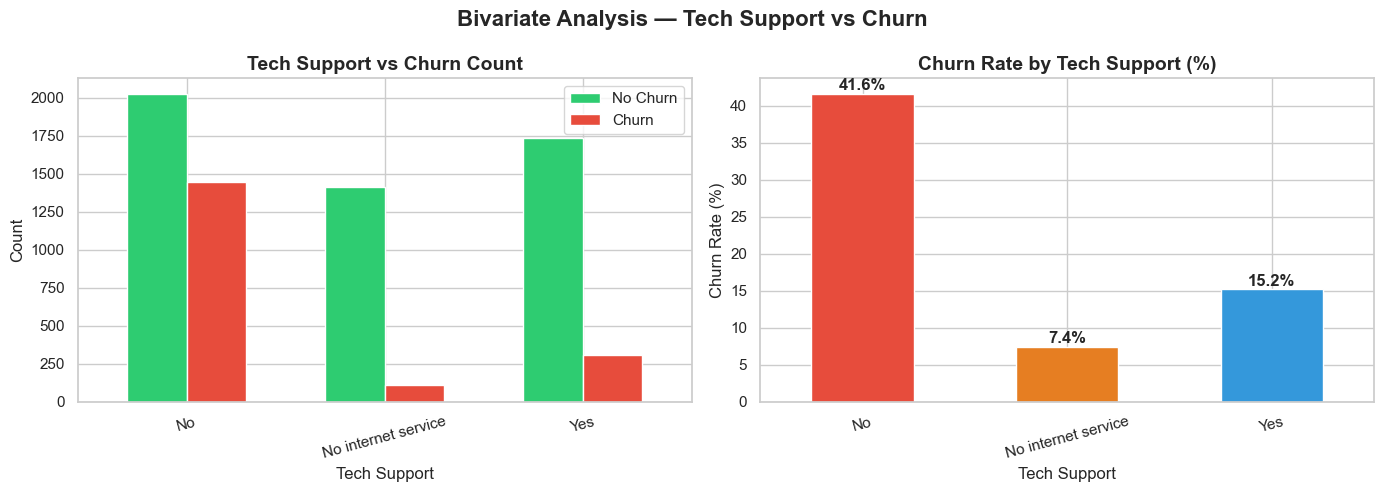

In [33]:
# ── Cell 11 — Churn vs Tech Support ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
tech_churn = df.groupby(['TechSupport', 'Churn']).size().unstack()
tech_churn.plot(kind='bar', ax=axes[0],
                color=['#2ecc71', '#e74c3c'],
                edgecolor='white', width=0.6)
axes[0].set_title('Tech Support vs Churn Count', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tech Support')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(['No Churn', 'Churn'])

# Churn rate by tech support
churn_rate_tech = df.groupby('TechSupport')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

churn_rate_tech.plot(kind='bar', ax=axes[1],
                     color=['#e74c3c', '#e67e22', '#3498db'],
                     edgecolor='white', width=0.5)
axes[1].set_title('Churn Rate by Tech Support (%)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tech Support')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

# Add value labels
for i, v in enumerate(churn_rate_tech.values):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.suptitle('Bivariate Analysis — Tech Support vs Churn',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/techsupport_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- Customers **without tech support** have significantly higher churn
- Customers **with tech support** are more likely to stay
- **No internet service** customers rarely churn — they are on basic plans
- Key insight: Tech support acts as a **retention tool**

## 7. Multivariate Analysis
Examining three variables simultaneously — tenure, monthly charges,
and churn status to identify high-risk customer segments.

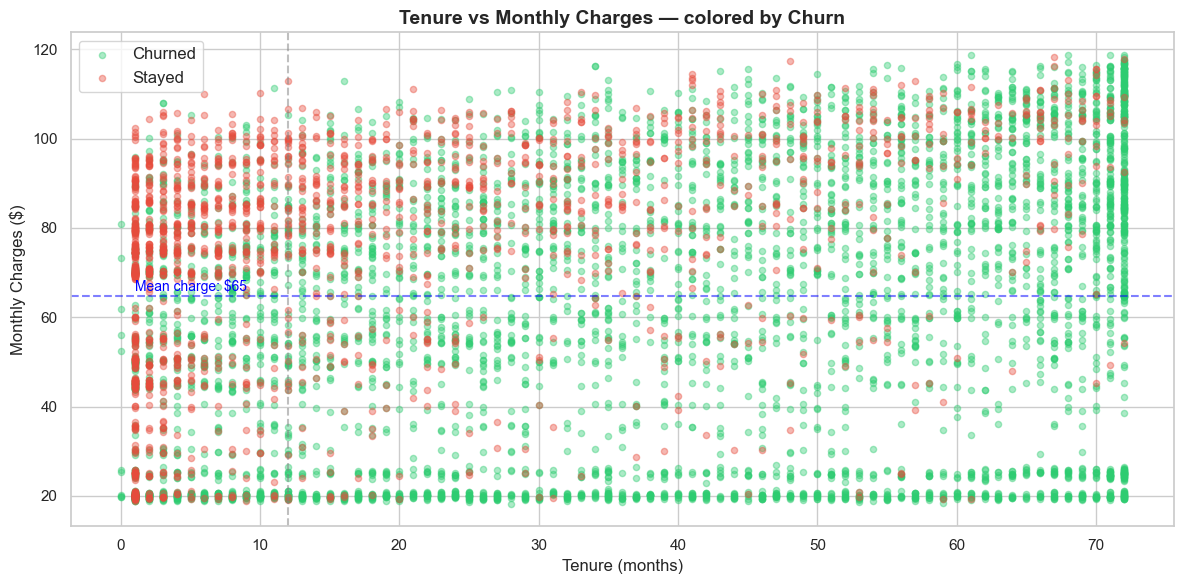

In [27]:
# ── Cell 9 — Multivariate Analysis ───────────────────────────────────────

fig, axes = plt.subplots(1, 1, figsize=(12, 6))

# Scatter plot — tenure vs monthly charges colored by churn
colors = {'Yes': '#e74c3c', 'No': '#2ecc71'}

for churn_val, group in df.groupby('Churn'):
    axes.scatter(group['tenure'], 
                 group['MonthlyCharges'],
                 c=colors[churn_val],
                 label=f"Churn: {churn_val}",
                 alpha=0.4,
                 s=20)

axes.set_title('Tenure vs Monthly Charges — colored by Churn',
               fontsize=14, fontweight='bold')
axes.set_xlabel('Tenure (months)')
axes.set_ylabel('Monthly Charges ($)')
axes.legend(['Churned', 'Stayed'], fontsize=12)

# Add reference lines
axes.axvline(12, color='gray', linestyle='--', 
             alpha=0.5, label='12 month mark')
axes.axhline(df['MonthlyCharges'].mean(), color='blue',
             linestyle='--', alpha=0.5)
axes.text(1, df['MonthlyCharges'].mean() + 1, 
          f"Mean charge: ${df['MonthlyCharges'].mean():.0f}", 
          color='blue', fontsize=10)

plt.tight_layout()
plt.savefig('../data/multivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- **Red dots (churned)** are heavily concentrated in:
  - **Low tenure (0-12 months)** — new customers
  - **High monthly charges ($70-100+)** — expensive plans
- **Green dots (stayed)** are spread across:
  - **Higher tenure** — long term customers
  - **Wider charge range** — comfortable with their plan
- Key insight: **High bill + New customer = Highest churn risk**
- This is the most valuable segment for business intervention 

## 8. Correlation Heatmap
Examining relationships between numerical features
to identify which variables are most related to each other.

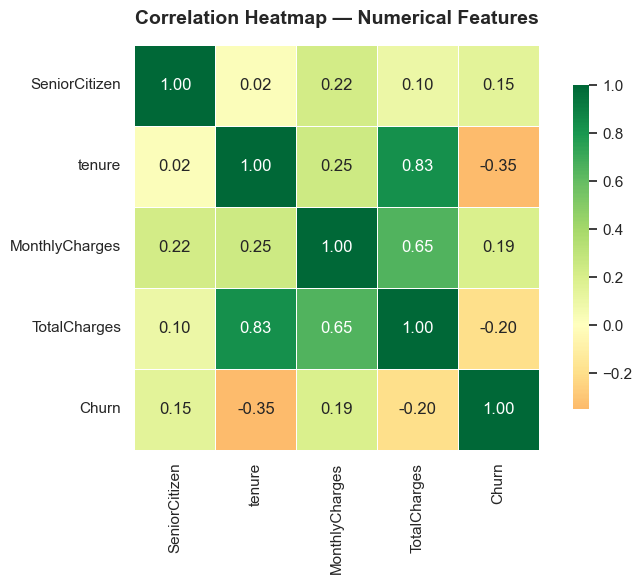

In [30]:
# ── Cell 10 — Correlation Heatmap ────────────────────────────────────────

# Convert churn to numeric for correlation
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select numerical columns only
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 
            'TotalCharges', 'Churn']

corr_matrix = df_corr[num_cols].corr().round(2)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap — Numerical Features',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- **Tenure vs Churn: -0.35** — longer tenure = less churn
- **MonthlyCharges vs Churn: +0.19** — higher charges = more churn
- **TotalCharges vs Tenure: +0.83** — strong positive (obvious — longer 
  stay = more total paid)
- **MonthlyCharges vs TotalCharges: +0.65** — higher monthly = higher total
- Key takeaway: **tenure is the strongest predictor of churn**

## 9. EDA Summary & Key Insights

In [36]:
# ── Cell 12 — EDA Summary ────────────────────────────────────────────────

print("=" * 55)
print("     EDA SUMMARY — CUSTOMER CHURN PREDICTION")
print("=" * 55)

print("""
ABOUT THE DATASET
───────────────────────────────────────────────
  We analyzed 7,043 customer records from a telecom
  company, each with 21 attributes covering their 
  demographics, services, and billing information.

WHO IS CHURNING?
───────────────────────────────────────────────
  Out of every 100 customers:
  → 73 stayed with the company
  → 27 left (churned)
  
  This means churn is a real and significant problem
  the business needs to address.

WHAT MAKES A CUSTOMER LEAVE?
───────────────────────────────────────────────
  1. SHORT TENURE
     Customers in their first year are most likely
     to leave. The longer someone stays, the more
     loyal they become.

  2. MONTH-TO-MONTH CONTRACT
     42% of month-to-month customers churn.
     Customers on 2-year contracts? Only 3%.
     No commitment = easy to leave.

  3. HIGH MONTHLY BILL
     Customers paying $70+ per month are more
     likely to churn — especially if they are new.

  4. NO TECH SUPPORT
     Customers without tech support churn more.
     Having support makes customers feel valued
     and less likely to switch.

WHO IS MOST AT RISK?
───────────────────────────────────────────────
  The most likely customer to churn looks like:
  ⚠️  Joined less than 12 months ago
  ⚠️  On a month-to-month contract
  ⚠️  Paying more than $70/month
  ⚠️  No tech support subscription

WHAT SHOULD THE BUSINESS DO?
───────────────────────────────────────────────
  → Offer discounts to new high-paying customers
  → Incentivize switching to longer contracts
  → Bundle tech support with expensive plans
  → Flag at-risk customers early using ML model

NEXT STEPS
───────────────────────────────────────────────
  → Data Transformation  (encoding, scaling)
  → Model Training       (Random Forest, XGBoost)
  → Model Evaluation     (Accuracy, F1, AUC)
  → MLflow Integration   (experiment tracking)
""")
print("=" * 55)
print("EDA Complete")

     EDA SUMMARY — CUSTOMER CHURN PREDICTION

ABOUT THE DATASET
───────────────────────────────────────────────
  We analyzed 7,043 customer records from a telecom
  company, each with 21 attributes covering their 
  demographics, services, and billing information.

WHO IS CHURNING?
───────────────────────────────────────────────
  Out of every 100 customers:
  → 73 stayed with the company
  → 27 left (churned)
  
  This means churn is a real and significant problem
  the business needs to address.

WHAT MAKES A CUSTOMER LEAVE?
───────────────────────────────────────────────
  1. SHORT TENURE
     Customers in their first year are most likely
     to leave. The longer someone stays, the more
     loyal they become.

  2. MONTH-TO-MONTH CONTRACT
     42% of month-to-month customers churn.
     Customers on 2-year contracts? Only 3%.
     No commitment = easy to leave.

  3. HIGH MONTHLY BILL
     Customers paying $70+ per month are more
     likely to churn — especially if they are new.